# Chua's Model
Define and simulate the Chua model as in the main paper

In [1]:
from scipy.integrate import solve_ivp 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import torch 
from torch import nn 
from torchdiffeq import odeint
import pysindy as ps 
from sr3_modified import my_SR3 as MySR3

$$
\begin{align}
\dot x &= 10y-10x^3-1.43x \\
\dot y &= x-y+z \\
\dot z &= -16 y
\end{align}
$$

In [2]:
def chua_model(t, xyz, alpha, beta, gamma, a, c):
    x,y,z = xyz 
    return np.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

In [3]:
T_MAX = 50

ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

sol = solve_ivp(chua_model, [0,T_MAX],
                y0 = (0, 0.1, 0.3), 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-9, rtol=1e-9,
)


In [4]:
sol.y[:, 0]

array([0. , 0.1, 0.3])

Text(0.5, 1.0, 'Time Series Plot')

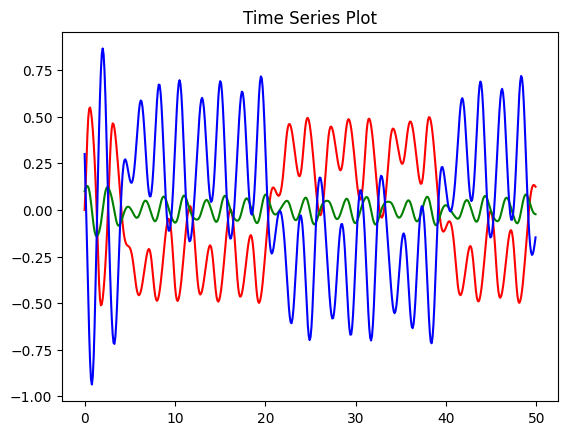

In [5]:
plt.plot(sol.t, sol.y[0, :], color="r")
plt.plot(sol.t, sol.y[1, :], color="g")
plt.plot(sol.t, sol.y[2, :], color="b")
plt.title("Time Series Plot")

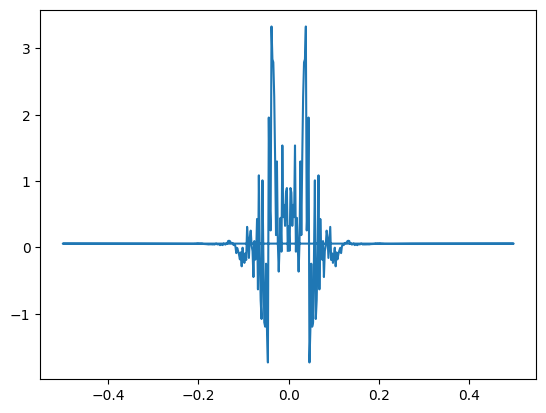

In [6]:
np.fft.fft(sol.y[0, :])
plt.plot(np.fft.fftfreq(sol.t.shape[-1]), np.fft.fft(sol.y[1, :]).real)


In [7]:
fig = px.line_3d(x=sol.y[0, :], y=sol.y[1, :], z=sol.y[2, :])
fig.show()

In this notebook, we will see if SciML is able to learn the double scroll attractor

# Using UDE To Learn Chua's Model
Suppose we do not know the linear term, so we get instead the following UDE:

$$
\begin{align}
\dot x &= \alpha(y-U(\bullet)) \nonumber \\
\dot y &= x-y+z  \nonumber\\
\dot z &= -\beta y - \gamma z
\end{align}
$$

**Q.** In the UDE, should we include only $x$ or also $y,z$, or a mix of both cases? 

The aim of this experiment is to see which one is the best at:
1) Reproducing the double scroll attractor, with validation metric as an unseen trajectory 
2) Identifying the model with SINDy

Also, we consider using the FFT transform as a preprocessing step for the UDE learning process. Let's see if it helps or not

We are considering the PEM-UDE variant

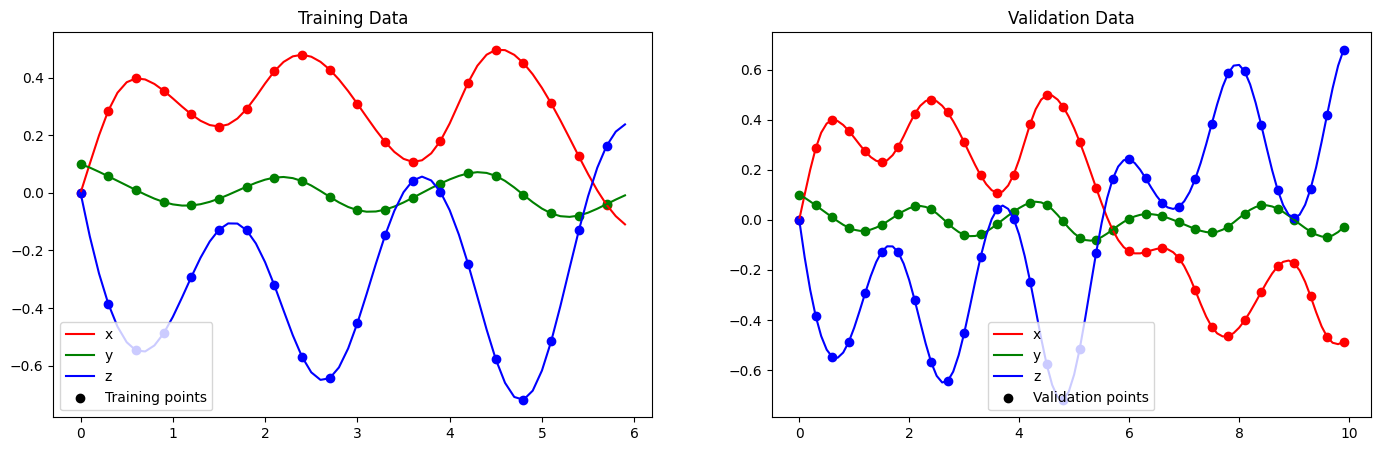

In [9]:
# generate train and val data
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, alpha, beta, gamma, a, c):
    x,y,z = xyz 
    return np.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

# 1: TRAINING DATA
plt.sca(axes[0])

T_MAX = 6
delta_t = 3

sol = solve_ivp(chua_model, [0,T_MAX],
                y0 = (0.0001, 0.1, 0), 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)
data_train = sol.y.T[::delta_t, :]
t_train = sol.t[::delta_t]

for i in range(3):
    col = col_dict[i]
    plt.plot(sol.t, sol.y[i, :], color=col, label=var_dict[i])
    plt.scatter(t_train, data_train[:, i], color=col)

plt.scatter([], [], color="k", label="Training points")

plt.title("Training Data")

plt.legend()

# 2: VAL DATA
plt.sca(axes[1])

T_MAX = 10.
delta_t = 3

sol = solve_ivp(chua_model, [0,T_MAX],
                y0 = (0.0001, 0.1, 0.0001), 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)

data_val = sol.y.T[::delta_t, :]
t_val = sol.t[::delta_t]

for i in range(3):
    col = col_dict[i]
    plt.plot(sol.t, sol.y[i, :], color=col, label=var_dict[i])
    plt.scatter(t_val, data_val[:, i], color=col)

plt.scatter([], [], color="k", label="Validation points")

plt.title("Validation Data")

plt.legend()

plt.show()

torch_dtype = torch.float32

# convert data to torch
t_train_torch = torch.tensor(t_train, dtype=torch_dtype) 
t_val_torch = torch.tensor(t_val, dtype=torch_dtype)
data_train_torch = torch.tensor(data_train, dtype=torch_dtype, requires_grad=True)
data_val_troch = torch.tensor(data_val, dtype=torch_dtype, requires_grad=True)

In [10]:
def batched_solve_and_evaluate(ude, X, T, method = 'dopri5', args = None):
    loss = torch.tensor(0.0, requires_grad=True)

    x0_i = X[0, :].clone().detach()

    for i in range(len(T)-1):
        x_pred = odeint(ude, x0_i, T[i:i+2], method=method, options=args)
        loss = loss + (torch.sum((x_pred - X[i+1]) ** 2, dim=1)).mean()
        x0_i = x_pred[-1]

    loss = loss/len(T)


    return loss 


In [ ]:
def batched_solve_and_evaluate(ude, X, T, method = 'dopri5', args = None):
    loss = torch.tensor(0.0, requires_grad=True)

    x0_i = X[0, :].clone().detach()

    for i in range(len(T)-1):
        x_pred = odeint(ude, x0_i, T[i:i+2], method=method, options=args)
        loss = loss + (torch.sum((x_pred - X[i+1]) ** 2, dim=1)).mean()
        x0_i = x_pred[-1]

    loss = loss/len(T)


    return loss 

def train_ude(T_train, X_train, T_val, X_val, ude: nn.Module, n_epochs: int, lr: float, verbose: bool = False, solver='dopri5'):
    print("Training model...")
    x0_train = X_train[0, :].clone().detach()
    x0_val = X_val[0, :].clone().detach()

    train_losses = []
    val_losses = []

    optimizer = torch.optim.Adam(ude.parameters(), lr)

    for EPOCH in range(0, n_epochs):
        optimizer.zero_grad()

        # get forward solution
        loss = batched_solve_and_evaluate(ude, X_train, T_train, method=solver)

        loss.backward()
        optimizer.step()

        if EPOCH % 100 == 0:
            with torch.no_grad():
                val_loss = batched_solve_and_evaluate(ude, X_val, T_val, method=solver)
                val_losses.append(val_loss.item())
            
        train_losses.append(loss.item())

        if verbose:
            if EPOCH % 100 == 0:
                print(f"{EPOCH}\t{loss:.4e}\t{val_loss:.4e}")
            else:
                print(f"{EPOCH}\t{loss:.4e}")
        

    return train_losses, val_losses

In [83]:
def train_ude_alt(T_train, X_train, T_val, X_val, ude: nn.Module, n_epochs: int, lr: float, verbose: bool = False, solver="rk4"):
    print("Training model...")
    x0_train = X_train[0, :].clone().detach()
    x0_val = X_val[0, :].clone().detach()

    train_losses = []
    val_losses = []

    optimizer = torch.optim.Adam(ude.parameters(), lr)

    for EPOCH in range(0, n_epochs):
        optimizer.zero_grad()

        # get forward solution
        x_pred = odeint(ude, x0_train, T_train, method=solver)

        loss = torch.mean((x_pred-X_train)**2)

        loss.backward()
        optimizer.step()

        if EPOCH % 100 == 0:
            with torch.no_grad():
                x_pred = odeint(ude, x0_val, T_val, method=solver)

                val_loss = torch.mean((x_pred-X_val)**2)
                val_losses.append(val_loss.item())
                
        train_losses.append(loss.item())

        if verbose:
            if EPOCH % 100 == 0:
                print(f"{EPOCH}\t{loss:.4e}\t{val_loss:.4e}")
            else:
                print(f"{EPOCH}\t{loss:.4e}")
        

    return train_losses, val_losses

## Baseline: NDE

In [13]:
class nde_baseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.netx = nn.Sequential(
            nn.Linear(3, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )
        self.nety = nn.Sequential(
            nn.Linear(3, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )
        self.netz = nn.Sequential(
            nn.Linear(3, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )
        
        with torch.no_grad():
            self.netx[-1].weight.zero_()
            self.netx[-1].bias.zero_()
            self.nety[-1].weight.zero_()
            self.nety[-1].bias.zero_()
            self.netz[-1].weight.zero_()
            self.netz[-1].bias.zero_()

    def forward(self, t, data):
        return torch.stack([
            self.netx(data).squeeze(),
            self.nety(data).squeeze(),
            self.netz(data).squeeze()
        ])

In [14]:
device ="cpu"

In [20]:
nde = nde_baseline().to(device)

train_loss, val_loss = train_ude(t_train_torch.to(device), data_train_torch.to(device), t_val_torch.to(device), data_val_troch.to(device), nde, 501, 0.005, True)

Training model...
0	2.6998e-01	2.7717e-01
1	2.3506e-01
2	2.0561e-01
3	1.8256e-01
4	1.6583e-01
5	1.5478e-01
6	1.5064e-01
7	1.5394e-01
8	1.6044e-01
9	1.6446e-01
10	1.6449e-01
11	1.6169e-01
12	1.5772e-01
13	1.5387e-01
14	1.5085e-01
15	1.4891e-01
16	1.4800e-01
17	1.4792e-01
18	1.4840e-01
19	1.4917e-01
20	1.4993e-01
21	1.5047e-01
22	1.5064e-01
23	1.5043e-01
24	1.4995e-01
25	1.4934e-01
26	1.4871e-01
27	1.4817e-01
28	1.4776e-01
29	1.4749e-01
30	1.4737e-01
31	1.4735e-01
32	1.4741e-01
33	1.4750e-01
34	1.4756e-01
35	1.4758e-01
36	1.4752e-01
37	1.4737e-01
38	1.4715e-01
39	1.4688e-01
40	1.4659e-01
41	1.4634e-01
42	1.4612e-01
43	1.4595e-01
44	1.4581e-01
45	1.4568e-01
46	1.4552e-01
47	1.4531e-01
48	1.4504e-01
49	1.4470e-01
50	1.4430e-01
51	1.4385e-01
52	1.4335e-01
53	1.4280e-01
54	1.4219e-01
55	1.4151e-01
56	1.4073e-01
57	1.3986e-01
58	1.3888e-01
59	1.3778e-01
60	1.3655e-01
61	1.3518e-01
62	1.3362e-01
63	1.3188e-01
64	1.2998e-01
65	1.2794e-01
66	1.2575e-01
67	1.2340e-01
68	1.2092e-01
69	1.1837e-01
7

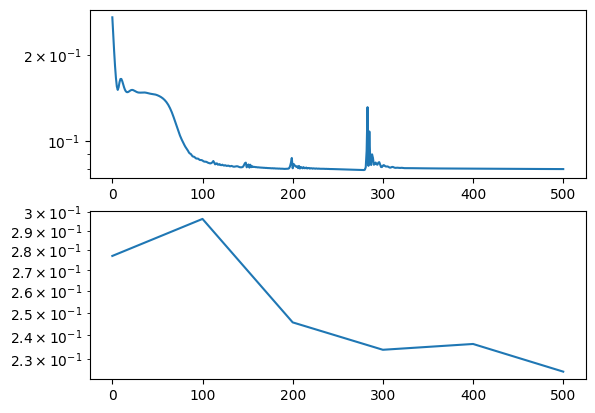

In [21]:
fig, axes = plt.subplots(2)

plt.sca(axes[0])
plt.semilogy(np.array(range(len(train_loss))), train_loss)
plt.sca(axes[1])
plt.semilogy(100*np.array(range(len(val_loss))), val_loss)

plt.show()

## Case 1: only x

```
def chua_model(t, xyz, alpha, beta, gamma, a, c):
    x,y,z = xyz 
    return np.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])
```

In [22]:
class ude_chua_x(nn.Module):
    def __init__(self, alpha, beta, gamma):
        super().__init__()

        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

        with torch.no_grad():
            self.net[-1].weight.zero_()
            self.net[-1].bias.zero_()


    def forward(self, t, data):
        x,y,z = data 

        gx = self.net(x.reshape(1)).squeeze()

        dx = self.alpha * (y - gx)
        dy = x - y + z
        dz = -self.beta * y - self.gamma * z

        return torch.stack([dx, dy, dz])

In [24]:
ude = ude_chua_x(ALPHA, BETA, GAMMA).to(device)

t_loss, v_loss = train_ude(t_train_torch.to(device), data_train_torch.to(device), t_val_torch.to(device), data_val_troch.to(device), ude, 501, 0.005, True)

Training model...
0	2.6738e-01	7.1715e+00
1	1.2747e+00
2	2.4558e-01
3	3.1020e-01
4	6.1410e-01
5	4.9954e-01
6	2.4850e-01
7	1.5451e-01
8	2.4781e-01
9	3.5416e-01
10	3.4165e-01
11	2.4813e-01
12	1.6961e-01
13	1.5735e-01
14	1.9638e-01
15	2.3782e-01
16	2.4506e-01
17	2.1691e-01
18	1.7805e-01
19	1.5534e-01
20	1.5949e-01
21	1.8046e-01
22	1.9753e-01
23	1.9684e-01
24	1.8073e-01
25	1.6241e-01
26	1.5395e-01
27	1.5811e-01
28	1.6837e-01
29	1.7539e-01
30	1.7398e-01
31	1.6590e-01
32	1.5735e-01
33	1.5385e-01
34	1.5648e-01
35	1.6175e-01
36	1.6482e-01
37	1.6335e-01
38	1.5885e-01
39	1.5485e-01
40	1.5395e-01
41	1.5597e-01
42	1.5857e-01
43	1.5942e-01
44	1.5795e-01
45	1.5549e-01
46	1.5395e-01
47	1.5423e-01
48	1.5562e-01
49	1.5668e-01
50	1.5647e-01
51	1.5526e-01
52	1.5412e-01
53	1.5389e-01
54	1.5450e-01
55	1.5522e-01
56	1.5534e-01
57	1.5480e-01
58	1.5411e-01
59	1.5385e-01
60	1.5411e-01
61	1.5453e-01
62	1.5467e-01
63	1.5441e-01
64	1.5402e-01
65	1.5385e-01
66	1.5398e-01
67	1.5421e-01
68	1.5429e-01
69	1.5415e-01
7

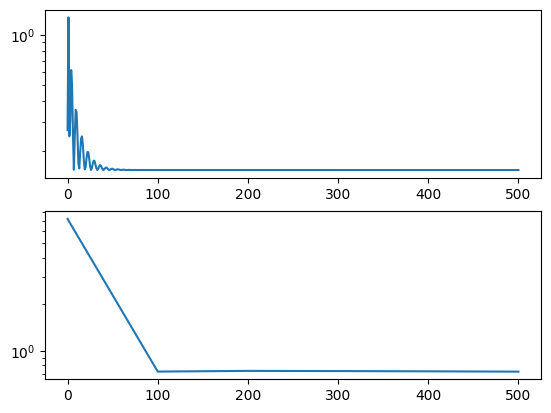

In [25]:
fig, axes = plt.subplots(2)

plt.sca(axes[0])
plt.semilogy(np.array(range(len(t_loss))), t_loss)
plt.sca(axes[1])
plt.semilogy(100*np.array(range(len(v_loss))), v_loss)

plt.show()

## Case 2: xyz

In [26]:
class ude_chua_xyz(nn.Module):
    def __init__(self, alpha, beta, gamma):
        super().__init__()

        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        self.net = nn.Sequential(
            nn.Linear(3, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )
        
        with torch.no_grad():
            self.net[-1].weight.zero_()
            self.net[-1].bias.zero_()

    def forward(self, t, data):
        x,y,z = data 


        gx = self.net(data).squeeze()


        dx = self.alpha * (y - gx)
        dy = x - y + z
        dz = -self.beta * y - self.gamma * z

        return torch.stack([dx, dy, dz])

In [27]:
ude_xyz = ude_chua_xyz(ALPHA, BETA, GAMMA).to(device)
ude_xyz.to(torch_dtype)

tl, vl = train_ude(t_train_torch.to(device), data_train_torch.to(device), t_val_torch.to(device), data_val_troch.to(device), ude_xyz, 501, 0.005, True)

Training model...
0	2.6738e-01	5.0175e+00
1	8.0516e-01
2	2.2911e-01
3	2.3219e-01
4	4.2792e-01
5	3.5614e-01
6	1.9854e-01
7	1.5808e-01
8	2.3103e-01
9	2.8390e-01
10	2.5121e-01
11	1.8558e-01
12	1.5415e-01
13	1.7181e-01
14	2.0499e-01
15	2.1473e-01
16	1.9435e-01
17	1.6614e-01
18	1.5399e-01
19	1.6323e-01
20	1.7985e-01
21	1.8605e-01
22	1.7686e-01
23	1.6191e-01
24	1.5399e-01
25	1.5749e-01
26	1.6632e-01
27	1.7098e-01
28	1.6736e-01
29	1.5933e-01
30	1.5403e-01
31	1.5514e-01
32	1.6002e-01
33	1.6302e-01
34	1.6118e-01
35	1.5662e-01
36	1.5373e-01
37	1.5460e-01
38	1.5741e-01
39	1.5880e-01
40	1.5738e-01
41	1.5475e-01
42	1.5350e-01
43	1.5444e-01
44	1.5604e-01
45	1.5633e-01
46	1.5504e-01
47	1.5364e-01
48	1.5349e-01
49	1.5439e-01
50	1.5504e-01
51	1.5462e-01
52	1.5366e-01
53	1.5320e-01
54	1.5359e-01
55	1.5411e-01
56	1.5402e-01
57	1.5341e-01
58	1.5301e-01
59	1.5317e-01
60	1.5349e-01
61	1.5344e-01
62	1.5303e-01
63	1.5275e-01
64	1.5285e-01
65	1.5301e-01
66	1.5289e-01
67	1.5257e-01
68	1.5242e-01
69	1.5249e-01
7

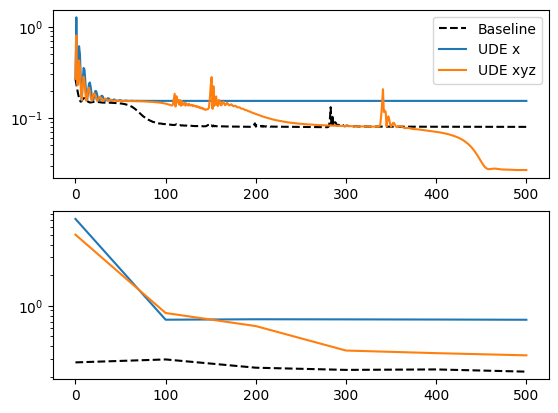

In [28]:
fig, axes = plt.subplots(2)

plt.sca(axes[0])
plt.semilogy(np.array(range(len(tl))), train_loss, label="Baseline", color="k", linestyle="--")
plt.semilogy(np.array(range(len(tl))), t_loss, label="UDE x")
plt.semilogy(np.array(range(len(tl))), tl, label="UDE xyz")

plt.ylim(None)

plt.legend()
plt.sca(axes[1])
plt.semilogy(100*np.array(range(len(vl))), val_loss, color="k", linestyle="--")
plt.semilogy(100*np.array(range(len(vl))), v_loss)
plt.semilogy(100*np.array(range(len(vl))), vl)
plt.ylim(None)

plt.show()

## PEM UDEs

### Pem XYZ

In [71]:

class PEM_ude_chua_x(nn.Module):
    def __init__(self, alpha, beta, gamma, K, obs_fn):
        super().__init__()

        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        self.net = nn.Sequential(
            nn.Linear(3, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

        with torch.no_grad():
            self.net[-1].weight.zero_()
            self.net[-1].bias.zero_()

        self.obs_fn = obs_fn
        self.register_buffer("K", torch.tensor(K, dtype=torch_dtype))

    def forward(self, t, data):
        x, y, z = data

        gx = self.net(data).squeeze()

        dx = self.alpha * (y - gx)
        dy = x - y + z
        dz = -self.beta * y - self.gamma * z

        y_hat = self.obs_fn(t).to(data) # obs

        ex = y_hat[0] - x
        ey = y_hat[1] - y
        ez = y_hat[2] - z

        dx = dx + self.K[0] * ex
        dy = dy + self.K[1] * ey
        dz = dz + self.K[2] * ez

        return torch.stack([dx, dy, dz])

In [ ]:
class LinearInterpolator:
    def __init__(self, t_obs, y_obs):
        # t_obs: (N,)
        # y_obs: (N, 3)
        self.t_obs = t_obs
        self.y_obs = y_obs

    def __call__(self, t):
        # assumes scalar t tensor
        idx = torch.searchsorted(self.t_obs, t.clamp(self.t_obs[0], self.t_obs[-1]))
        idx = torch.clamp(idx, 1, len(self.t_obs) - 1)

        t0 = self.t_obs[idx - 1]
        t1 = self.t_obs[idx]
        y0 = self.y_obs[idx - 1]
        y1 = self.y_obs[idx]

        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1 - w) * y0 + w * y1

In [ ]:
obs_fn = LinearInterpolator(t_train_torch, data_train_torch)   # y_obs shape (N, 3)
model = PEM_ude_chua_x(ALPHA, BETA, GAMMA, K=(0.3, 0.3, 0.3), obs_fn=obs_fn)
pem_t, pem_v = train_ude(t_train_torch.to(device), data_train_torch.to(device), t_val_torch.to(device), data_val_troch.to(device), model, 501, 0.005, True)

Training model...
0	1.3349e-01	1.6290e+00
1	3.9427e-01
2	1.3856e-01
3	1.6914e-01
4	2.4768e-01
5	2.0217e-01
6	1.3307e-01
7	1.2314e-01
8	1.6124e-01
9	1.7811e-01
10	1.5552e-01
11	1.2642e-01
12	1.1921e-01
13	1.3321e-01
14	1.4621e-01
15	1.4320e-01
16	1.2978e-01
17	1.1957e-01
18	1.1981e-01
19	1.2700e-01
20	1.3253e-01
21	1.3120e-01
22	1.2494e-01
23	1.1944e-01
24	1.1862e-01
25	1.2179e-01
26	1.2517e-01
27	1.2556e-01
28	1.2287e-01
29	1.1958e-01
30	1.1826e-01
31	1.1942e-01
32	1.2142e-01
33	1.2216e-01
34	1.2103e-01
35	1.1918e-01
36	1.1821e-01
37	1.1867e-01
38	1.1976e-01
39	1.2029e-01
40	1.1977e-01
41	1.1875e-01
42	1.1813e-01
43	1.1833e-01
44	1.1893e-01
45	1.1923e-01
46	1.1891e-01
47	1.1832e-01
48	1.1800e-01
49	1.1816e-01
50	1.1849e-01
51	1.1858e-01
52	1.1833e-01
53	1.1799e-01
54	1.1786e-01
55	1.1799e-01
56	1.1815e-01
57	1.1811e-01
58	1.1790e-01
59	1.1772e-01
60	1.1770e-01
61	1.1779e-01
62	1.1780e-01
63	1.1769e-01
64	1.1753e-01
65	1.1746e-01
66	1.1748e-01
67	1.1748e-01
68	1.1740e-01
69	1.1727e-01
7

In [ ]:
# save models and losses
# baseline
torch.save(nde.state_dict(), "./models_weights/31_1_nde.dm")
np.savetxt("./losses/31_1_nde_train.txt", train_loss)
np.savetxt("./losses/31_1_nde_val.txt", val_loss)

# ude x
torch.save(ude.state_dict(), "./models_weights/31_1_ude.dm")
np.savetxt("./losses/31_1_ude_train.txt", t_loss)
np.savetxt("./losses/31_1_ude_val.txt", v_loss)

# ude xyz
torch.save(ude_xyz.state_dict(), "./models_weights/31_1_ude_xyz.dm")
np.savetxt("./losses/31_1_ude_xyz_train.txt", tl)
np.savetxt("./losses/31_1_ude_xyz_val.txt", vl)

# pem ude xyz
torch.save(model.state_dict(), "./models_weights/31_1_ude_pem.dm")
np.savetxt("./losses/31_1_ude_pem_train.txt", pem_t)
np.savetxt("./losses/31_1_ude_pem_val.txt", pem_v)

### Pem X

In [42]:

class PEM_ude_chua_x_only(nn.Module):
    def __init__(self, alpha, beta, gamma, K, obs_fn):
        super().__init__()

        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 16),
            nn.SiLU(),
            nn.Linear(16, 1),
        )

        with torch.no_grad():
            self.net[-1].weight.zero_()
            self.net[-1].bias.zero_()

        self.obs_fn = obs_fn
        self.register_buffer("K", torch.tensor(K, dtype=torch_dtype))

    def forward(self, t, data):
        x, y, z = data

        gx = self.net(x.reshape(1)).squeeze()

        dx = self.alpha * (y - gx)
        dy = x - y + z
        dz = -self.beta * y - self.gamma * z

        y_hat = self.obs_fn(t).to(data) # obs

        ex = y_hat[0] - x
        ey = y_hat[1] - y
        ez = y_hat[2] - z

        dx = dx + self.K[0] * ex
        dy = dy + self.K[1] * ey
        dz = dz + self.K[2] * ez

        return torch.stack([dx, dy, dz])

In [ ]:
pem_model_x = PEM_ude_chua_x_only(ALPHA, BETA, GAMMA, (0.3, 0.3, 0.3), LinearInterpolator(t_train_torch, data_train_torch))
losses_train_pemx, losses_val_pemx = train_ude(t_train_torch, data_train_torch, t_val_torch, data_val_troch, pem_model_x, 501, 0.005, True, solver='dopri5')

In [91]:
# accidentally cancelled above cell's output; it's the same as the following:

print(np.loadtxt("./losses/31_1_ude_pem_xonly_train.txt"))

print(np.loadtxt("./losses/31_1_ude_pem_xonly_val.txt"))

[0.13348719 0.49734044 0.13597234 0.17666143 0.26811045 0.23776218
 0.1581044  0.11702792 0.14000055 0.18112633 0.18660596 0.15891963
 0.12798069 0.11548366 0.1231938  0.13844189 0.14712031 0.14365111
 0.13190992 0.12002043 0.11444213 0.11654953 0.12270208 0.12739804
 0.12726101 0.12281598 0.11721971 0.11364575 0.11337749 0.11551279
 0.11797817 0.11898623 0.117977   0.11566257 0.11335833 0.11214391
 0.1123055  0.11329875 0.11420224 0.11432794 0.11358716 0.11243391
 0.11148119 0.11111101 0.11130065 0.11172162 0.11198342 0.11186993
 0.11141987 0.11085916 0.11043914 0.11028953 0.1103662  0.11050282
 0.11053421 0.11038788 0.11011199 0.10982607 0.10963286 0.10956492
 0.10957565 0.10958473 0.10952839 0.10939354 0.10921665 0.10905192
 0.1089355  0.10887115 0.10883005 0.1087741  0.10868116 0.10855524
 0.10841604 0.10828676 0.10817842 0.10808585 0.10799117 0.10788073
 0.10774539 0.10759163 0.10742588 0.10725824 0.10708781 0.10690695
 0.10670632 0.10647652 0.10621075 0.10590754 0.1055637  0.1051

In [48]:
# save pem ude x results
torch.save(pem_model_x.state_dict(), "./models_weights/31_1_ude_pem_x_only.dm")
np.savetxt("./losses/31_1_ude_pem_xonly_train.txt", losses_train_pemx)
np.savetxt("./losses/31_1_ude_pem_xonly_val.txt", losses_val_pemx)

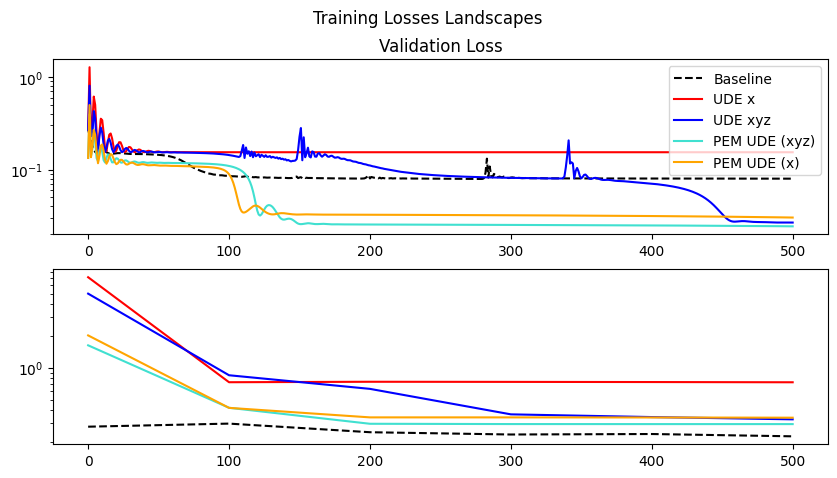

In [54]:
# load data and compare results

fig, axes = plt.subplots(2, figsize=(10, 5))

train_loss = np.loadtxt("./losses/31_1_nde_train.txt")
val_loss = np.loadtxt("./losses/31_1_nde_val.txt")

t_loss = np.loadtxt("./losses/31_1_ude_train.txt")
v_loss = np.loadtxt("./losses/31_1_ude_val.txt")

tl = np.loadtxt("./losses/31_1_ude_xyz_train.txt")
vl = np.loadtxt("./losses/31_1_ude_xyz_val.txt")

pem_t = np.loadtxt("./losses/31_1_ude_pem_train.txt")
pem_v = np.loadtxt("./losses/31_1_ude_pem_val.txt")

losses_train_pemx = np.loadtxt("./losses/31_1_ude_pem_xonly_train.txt")
losses_val_pemx = np.loadtxt("./losses/31_1_ude_pem_xonly_val.txt")

plt.sca(axes[0])
plt.title("Training Loss")
plt.semilogy(np.array(range(len(tl))), train_loss, label="Baseline", color="k", linestyle="--")
plt.semilogy(np.array(range(len(tl))), t_loss, label="UDE x", color="r")
plt.semilogy(np.array(range(len(tl))), tl, label="UDE xyz", color="b")
plt.semilogy(np.array(range(len(tl))), pem_t, label="PEM UDE (xyz)", color="turquoise")
plt.semilogy(np.array(range(len(tl))), losses_train_pemx, label="PEM UDE (x)", color="orange")

plt.legend()
plt.title("Validation Loss")
plt.sca(axes[1])
plt.semilogy(100*np.array(range(len(vl))), val_loss, color="k", linestyle="--")
plt.semilogy(100*np.array(range(len(vl))), v_loss, color="r")
plt.semilogy(100*np.array(range(len(vl))), vl, color="b")
plt.semilogy(100*np.array(range(len(vl))), pem_v, color="turquoise")
plt.semilogy(100*np.array(range(len(vl))), losses_val_pemx, color="orange")

plt.suptitle("Training Losses Landscapes")

plt.show()

In [ ]:
# Idea: fine-tune our PEM models further with RK4 and a very small learning late

In [92]:
pem_model_x = PEM_ude_chua_x_only(ALPHA, BETA, GAMMA, (0.3, 0.3, 0.3), LinearInterpolator(t_train_torch, data_train_torch))
pem_model_x.load_state_dict(torch.load("./models_weights/31_1_ude_pem_x_only.dm"))

losses_train_pemx_new, losses_val_pemx_new = train_ude_alt(t_train_torch, data_train_torch, t_val_torch, data_val_troch, pem_model_x, 5001, 1e-4, True, solver='rk4')

Training model...
0	5.1481e-03	1.1402e-01
1	5.0434e-03
2	4.9398e-03
3	4.8373e-03
4	4.7360e-03
5	4.6358e-03
6	4.5368e-03
7	4.4390e-03
8	4.3425e-03
9	4.2473e-03
10	4.1534e-03
11	4.0609e-03
12	3.9698e-03
13	3.8801e-03
14	3.7918e-03
15	3.7050e-03
16	3.6197e-03
17	3.5359e-03
18	3.4536e-03
19	3.3729e-03
20	3.2938e-03
21	3.2162e-03
22	3.1403e-03
23	3.0659e-03
24	2.9932e-03
25	2.9222e-03
26	2.8527e-03
27	2.7850e-03
28	2.7189e-03
29	2.6544e-03
30	2.5917e-03
31	2.5306e-03
32	2.4711e-03
33	2.4133e-03
34	2.3572e-03
35	2.3027e-03
36	2.2498e-03
37	2.1986e-03
38	2.1490e-03
39	2.1010e-03
40	2.0545e-03
41	2.0097e-03
42	1.9664e-03
43	1.9246e-03
44	1.8843e-03
45	1.8455e-03
46	1.8082e-03
47	1.7723e-03
48	1.7379e-03
49	1.7048e-03
50	1.6731e-03
51	1.6427e-03
52	1.6136e-03
53	1.5858e-03
54	1.5593e-03
55	1.5339e-03
56	1.5097e-03
57	1.4867e-03
58	1.4648e-03
59	1.4440e-03
60	1.4242e-03
61	1.4055e-03
62	1.3877e-03
63	1.3708e-03
64	1.3549e-03
65	1.3399e-03
66	1.3257e-03
67	1.3123e-03
68	1.2997e-03
69	1.2879e-03
7

In [93]:
model = PEM_ude_chua_x(ALPHA, BETA, GAMMA, (0.3, 0.3, 0.3), LinearInterpolator(t_train_torch, data_train_torch))
model.load_state_dict(torch.load("./models_weights/31_1_ude_pem.dm"))

losses_train_pem_new, losses_val_pem_new = train_ude_alt(t_train_torch, data_train_torch, t_val_torch, data_val_troch, model, 5001, 1e-4, True, solver='rk4')

Training model...
0	4.2535e-03	9.7592e-02
1	4.1550e-03
2	4.0581e-03
3	3.9629e-03
4	3.8694e-03
5	3.7777e-03
6	3.6878e-03
7	3.5998e-03
8	3.5136e-03
9	3.4292e-03
10	3.3468e-03
11	3.2663e-03
12	3.1877e-03
13	3.1111e-03
14	3.0365e-03
15	2.9638e-03
16	2.8931e-03
17	2.8244e-03
18	2.7577e-03
19	2.6929e-03
20	2.6302e-03
21	2.5694e-03
22	2.5106e-03
23	2.4537e-03
24	2.3988e-03
25	2.3457e-03
26	2.2946e-03
27	2.2453e-03
28	2.1978e-03
29	2.1522e-03
30	2.1084e-03
31	2.0663e-03
32	2.0259e-03
33	1.9872e-03
34	1.9501e-03
35	1.9147e-03
36	1.8808e-03
37	1.8485e-03
38	1.8177e-03
39	1.7883e-03
40	1.7603e-03
41	1.7338e-03
42	1.7085e-03
43	1.6845e-03
44	1.6618e-03
45	1.6403e-03
46	1.6200e-03
47	1.6007e-03
48	1.5826e-03
49	1.5654e-03
50	1.5493e-03
51	1.5341e-03
52	1.5198e-03
53	1.5064e-03
54	1.4938e-03
55	1.4820e-03
56	1.4709e-03
57	1.4606e-03
58	1.4509e-03
59	1.4419e-03
60	1.4334e-03
61	1.4255e-03
62	1.4182e-03
63	1.4114e-03
64	1.4050e-03
65	1.3991e-03
66	1.3936e-03
67	1.3885e-03
68	1.3837e-03
69	1.3793e-03
7

In [94]:
# save models and losses
torch.save(pem_model_x.state_dict(), "./models_weights/31_1_ude_pem_x_only_finetuned.dm")
torch.save(model.state_dict(), "./models_weights/31_1_ude_pem_x_only_finetuned.dm")

np.savetxt("./losses/31_1_ude_pem_xonly_train_finetuning.txt", losses_train_pemx_new)
np.savetxt("./losses/31_1_ude_pem_xonly_val_finetuning.txt", losses_val_pemx_new)

np.savetxt("./losses/31_1_ude_pem_train_finetuning.txt", losses_train_pem_new)
np.savetxt("./losses/31_1_ude_pem_val_finetuning.txt", losses_val_pem_new)

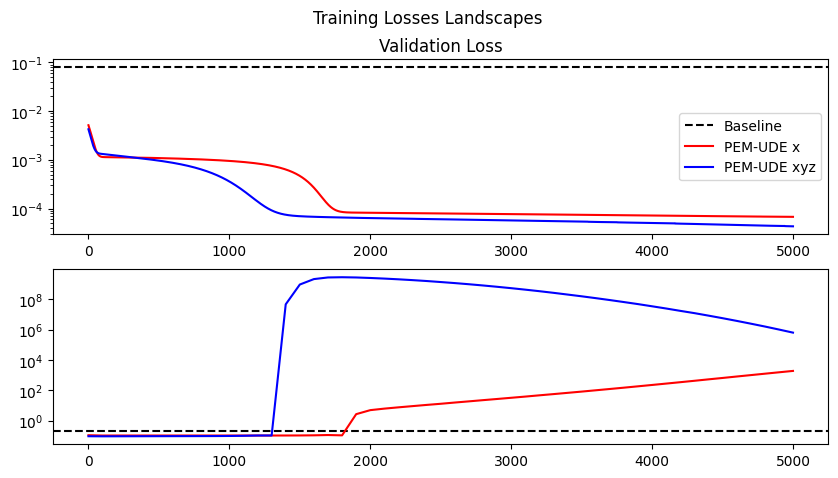

In [95]:
# load data and compare results

fig, axes = plt.subplots(2, figsize=(10, 5))

train_loss = np.loadtxt("./losses/31_1_nde_train.txt")
val_loss = np.loadtxt("./losses/31_1_nde_val.txt")

losses_train_pemx_new = np.loadtxt("./losses/31_1_ude_pem_xonly_train_finetuning.txt")
losses_val_pemx_new = np.loadtxt("./losses/31_1_ude_pem_xonly_val_finetuning.txt")

losses_train_pem_new = np.loadtxt("./losses/31_1_ude_pem_train_finetuning.txt")
losses_val_pem_new = np.loadtxt("./losses/31_1_ude_pem_val_finetuning.txt")

plt.sca(axes[0])
plt.title("Training Loss")
plt.axhline(train_loss[-1], label="Baseline", color="k", linestyle="--")
plt.semilogy(np.array(range(len(losses_train_pemx_new))), losses_train_pemx_new, label="PEM-UDE x", color="r")
plt.semilogy(np.array(range(len(losses_train_pemx_new))), losses_train_pem_new, label="PEM-UDE xyz", color="b")

plt.legend()
plt.title("Validation Loss")
plt.sca(axes[1])
plt.axhline(val_loss[-1], color="k", linestyle="--")
plt.semilogy(100*np.array(range(len(losses_val_pem_new))), losses_val_pemx_new, color="r")
plt.semilogy(100*np.array(range(len(losses_val_pem_new))), losses_val_pem_new, color="b")

plt.suptitle("Training Losses Landscapes")

plt.show()

Text(0.5, 1.0, 'Predicted and Real Trajectory')

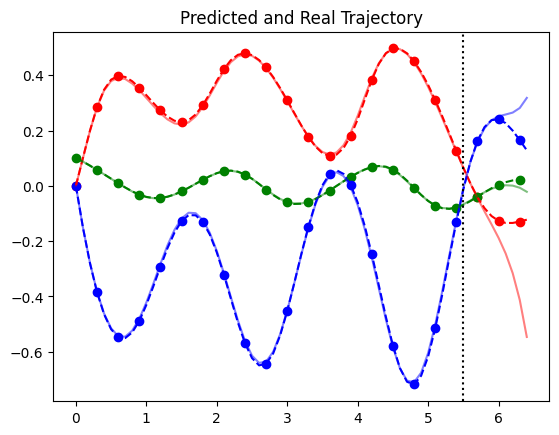

In [99]:
fig, axes = plt.subplots()
T_MAX = 6.5
delta_t = 3

sol = solve_ivp(chua_model, [0,T_MAX],
                y0 = (0.0001, 0.1, 0), 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)
data_train = sol.y.T[::delta_t, :]
t_train = sol.t[::delta_t]

for i in range(3):
    col = col_dict[i]
    plt.plot(sol.t, sol.y[i, :], color=col, linestyle="--")
    plt.scatter(t_train, data_train[:, i], color=col)

pred_traj = odeint(pem_model_x, data_train_torch[0], torch.arange(0, T_MAX, 0.1), method="rk4")
marker_traj = odeint(pem_model_x, data_train_torch[0], t_train_torch, method="rk4").detach().numpy().T


pred_traj_np = pred_traj.detach().numpy().T

for i in range(3):
    col = col_dict[i]
    plt.plot(sol.t, pred_traj_np[i, :], color=col, linestyle="-", alpha=0.5)

plt.axvline(5.5, color='k', linestyle=':')

plt.scatter([], [], color="k", label="Training points")
plt.plot([], [], color="k", linestyle="-", label="Learned Trajectory")
plt.plot([], [], color="k", linestyle="-", label="Predicted Trajectory")

plt.title("Predicted and Real Trajectory")

# SINDy Model Learning
this needs previous results, but we'll test with a baseline case

$$
\begin{align}
\dot x &= 10y-10x^3-1.43x \\
\dot y &= x-y+z \\
\dot z &= -16 y
\end{align}
$$

In [100]:
# load models, if already trained
pem_model = PEM_ude_chua_x(ALPHA, BETA, GAMMA, (0.3, 0.3, 0.3), LinearInterpolator(t_train_torch, data_train_torch))
pem_model.load_state_dict(torch.load("./models_weights/31_1_ude_pem_x_only_finetuned.dm"))

<All keys matched successfully>

In [186]:
# Baseline: No model (numerically computed derivatives)
sindy_baseline = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.SR3(max_iter=50000, regularizer='L1', verbose=True)
)

sindy_baseline.fit(data_train, t_train, feature_names=['x', 'y', 'z'])


sindy_baseline.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 1.1476e-28 ... 4.1053e-03 ... 3.4764e+00 ... 3.4805e+00
      5000 ... 1.5314e-01 ... 7.4552e-04 ... 2.1446e-01 ... 3.6835e-01
     10000 ... 1.5176e-01 ... 6.8730e-04 ... 2.0948e-01 ... 3.6193e-01
     15000 ... 1.5408e-01 ... 6.9473e-04 ... 2.0823e-01 ... 3.6301e-01
(x)' =  1.280 x +  10.059 y + -0.002 z + -1.075 x^2 + -3.239 x y + -6.116 x^3 + -0.078 z^4
(y)' =  0.808 x + -0.831 y +  0.828 z
(z)' = -15.089 y +  0.120 z + -0.796 y z + -0.031 z^2 +  1.051 x^3


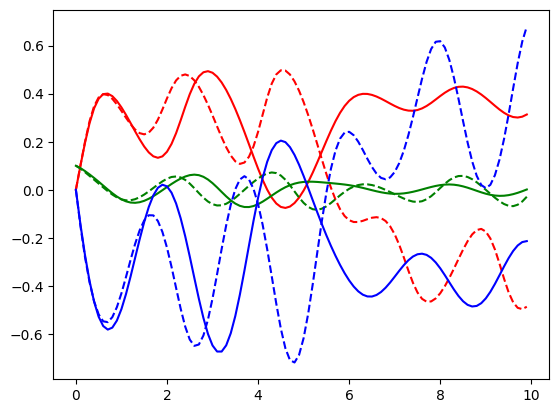

In [187]:
simulated_baseline = sindy_baseline.simulate(data_train[0], t_span_baseline := np.arange(0, 10, 0.1))
sol = solve_ivp(chua_model, t_span=(0,10),
                y0 = (0.0001, 0.1, 0), 
                t_eval = t_span_baseline, 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)

for i in range(3):
    col = col_dict[i]
    plt.plot(t_span_baseline, sol.y[i, :], color=col, linestyle="--")
    plt.plot(t_span_baseline, simulated_baseline[:, i], color=col)


In [188]:
# Train with PEM
X_dot = torch.zeros(data_train.shape)

for i, (t, x) in enumerate(zip(t_train, data_train)):

    X_dot[i, :] = pem_model(torch.tensor(t), torch.tensor(x, dtype=torch.float32))


In [189]:
sindy_ude = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.SR3(max_iter=100000, regularizer='L1', verbose=True)
)

sindy_ude.fit(data_train, t_train, feature_names=['x', 'y', 'z'], x_dot=X_dot.detach().numpy(), )

sindy_ude.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 4.2003e-29 ... 4.0228e-03 ... 1.5726e+00 ... 1.5767e+00
     10000 ... 6.2355e-02 ... 6.7934e-04 ... 2.0593e-01 ... 2.6897e-01
(x)' =  1.450 x +  10.548 y + -1.591 x^2 +  2.656 y z + -4.296 x^3 +  1.521 x^2 z
(y)' =  0.934 x + -0.857 y +  0.941 z
(z)' = -15.839 y +  0.121 z +  0.033 x^2 +  0.200 z^2


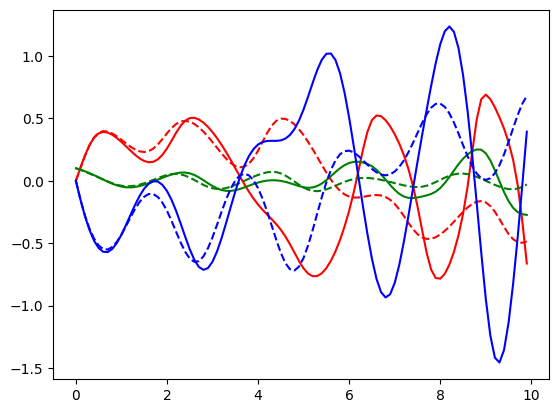

In [190]:
simulated_pem = sindy_ude.simulate(data_train[0], t_span_baseline := np.arange(0, 10, 0.1))

sol = solve_ivp(chua_model, [0,10],
                y0 = (0.0001, 0.1, 0), 
                t_eval = t_span_baseline, 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)

for i in range(3):
    col = col_dict[i]
    plt.plot(t_span_baseline, sol.y[i, :], color=col, linestyle="--")
    plt.plot(t_span_baseline, simulated_pem[:, i], color=col)


In [170]:
# more data??? (between 0, 5.5)
pred_traj = odeint(pem_model, data_train_torch[0], t_span:=torch.arange(0, 5, 0.1), method="rk4")

X_dot = torch.zeros_like(pred_traj)

for i, (t, x) in enumerate(zip(t_span, pred_traj)):

    X_dot[i, :] = pem_model(t, x)

sindy_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.SR3(max_iter=50000, regularizer='L1', verbose=True)
)

sindy_lots.fit(x=pred_traj.detach().numpy(), t=t_span.detach().numpy(), feature_names=['x','y','z'], x_dot=X_dot.detach().numpy())
sindy_lots.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 4.8617e-05 ... 4.1250e-03 ... 1.4058e+05 ... 1.4058e+05
      5000 ... 3.9212e-01 ... 4.1250e-03 ... 1.4056e+05 ... 1.4056e+05
     10000 ... 9.8175e-01 ... 4.1250e-03 ... 1.4055e+05 ... 1.4055e+05
     15000 ... 1.5953e+00 ... 4.1250e-03 ... 1.4053e+05 ... 1.4053e+05
     20000 ... 2.1966e+00 ... 4.1250e-03 ... 1.4051e+05 ... 1.4051e+05
     25000 ... 2.7753e+00 ... 4.1250e-03 ... 1.4049e+05 ... 1.4050e+05
     30000 ... 3.3285e+00 ... 4.1250e-03 ... 1.4048e+05 ... 1.4048e+05
     35000 ... 3.8560e+00 ... 4.1250e-03 ... 1.4046e+05 ... 1.4046e+05
     40000 ... 4.3589e+00 ... 4.1250e-03 ... 1.4044e+05 ... 1.4045e+05
     45000 ... 4.8389e+00 ... 4.1250e-03 ... 1.4042e+05 ... 1.4043e+05
(x)' = -64.092 x + -708.725 y +  50.520 z +  1030.137 x^2 +  9713.170 x y +  329.177 x z + -7011.816 y^2 +  4947.849 y z + -33.560 z^2 + -6747.343 x^3 + -46220.804 x^2 y + -14798.466 x^2 z 

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 50000 iterations.
  warnings.warn(


In [172]:
# more data??? (between 0, 5.5)
pred_traj = odeint(pem_model, data_train_torch[0], t_span:=torch.arange(0, 6, 0.2), method="dopri5")

X_dot = torch.zeros_like(pred_traj)

for i, (t, x) in enumerate(zip(t_span, pred_traj)):

    X_dot[i, :] = pem_model(t, x)

sindy_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(5, include_bias=False),
    optimizer=ps.SR3(max_iter=100000, regularizer='L1', verbose=True)
)

sindy_lots.fit(x=pred_traj.detach().numpy(), t=t_span.detach().numpy(), feature_names=['x','y','z'], x_dot=X_dot.detach().numpy())
sindy_lots.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 7.8646e-12 ... 4.1250e-03 ... 3.1304e+01 ... 3.1308e+01
     10000 ... 2.1082e-01 ... 1.9632e-03 ... 1.1045e+01 ... 1.1258e+01
     20000 ... 1.8343e-01 ... 1.1798e-03 ... 3.6161e+00 ... 3.8007e+00
     30000 ... 1.0988e-01 ... 9.4702e-04 ... 1.5032e+00 ... 1.6140e+00
     40000 ... 4.2338e-02 ... 8.4564e-04 ... 3.5877e-01 ... 4.0195e-01
     50000 ... 4.0113e-02 ... 6.1143e-04 ... 2.0716e-01 ... 2.4788e-01
     60000 ... 3.9935e-02 ... 6.0482e-04 ... 2.0718e-01 ... 2.4772e-01
     70000 ... 3.9630e-02 ... 5.9986e-04 ... 2.0730e-01 ... 2.4753e-01
     80000 ... 3.9472e-02 ... 5.9424e-04 ... 2.0735e-01 ... 2.4742e-01
(x)' =  1.635 x +  10.538 y +  0.035 z + -2.259 x^2 +  2.911 y z + -3.840 x^3 +  1.308 x^2 z
(y)' =  0.951 x + -0.918 y +  0.953 z
(z)' = -0.013 x + -15.905 y + -0.005 z +  0.015 z^2


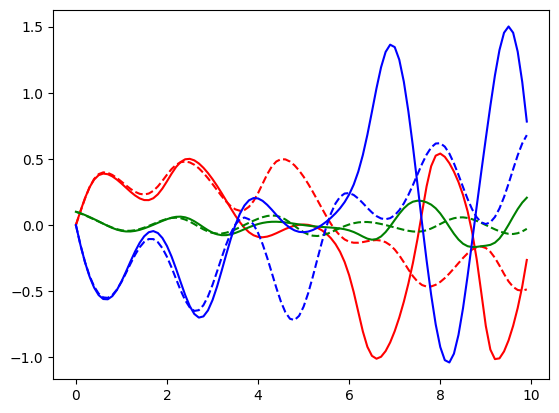

In [191]:
simulated_lots = sindy_lots.simulate(data_train[0], t_span_baseline := np.arange(0, 10, 0.1))

sol = solve_ivp(chua_model, [0,10],
                y0 = (0.0001, 0.1, 0), 
                t_eval = t_span_baseline, 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)

for i in range(3):
    col = col_dict[i]
    plt.plot(t_span_baseline, sol.y[i, :], color=col, linestyle="--")
    plt.plot(t_span_baseline, simulated_lots[:, i], color=col)


why are the two results so different???

In [195]:
t_span_baseline := np.arange(0, 10, 0.1)

SyntaxError: invalid syntax (1104816794.py, line 1)

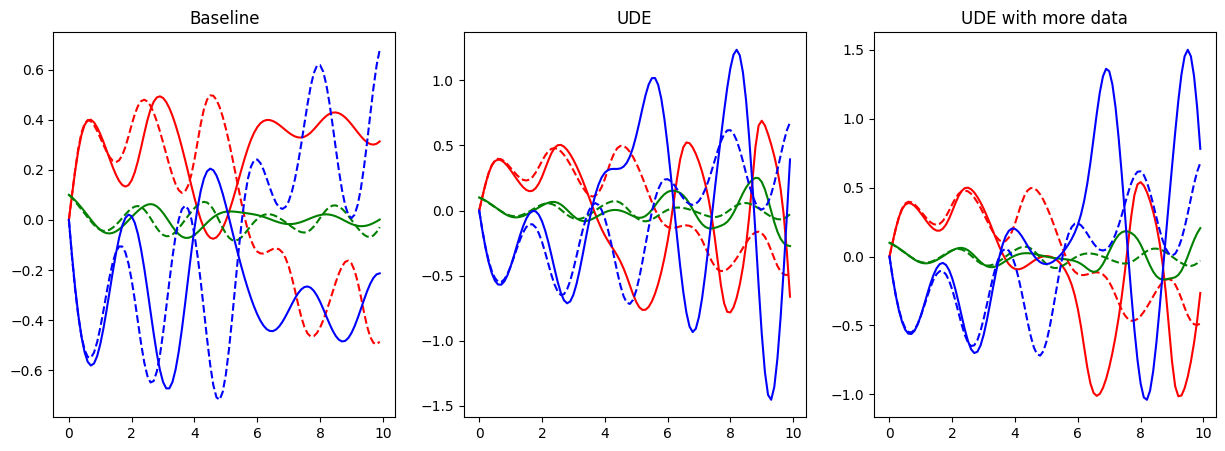

In [196]:
# compare each plot side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sol = solve_ivp(chua_model, t_span=(0,10),
                y0 = (0.0001, 0.1, 0), 
                t_eval = t_span_baseline, 
                args=(ALPHA, BETA, GAMMA, A, C),
                atol = 1e-8, rtol=1e-8,
)

plt.sca(axes[0])
plt.title("Baseline")

for i in range(3):
    col = col_dict[i]
    plt.plot(t_span_baseline, sol.y[i, :], color=col, linestyle="--")
    plt.plot(t_span_baseline, simulated_baseline[:, i], color=col)

plt.sca(axes[1])
for i in range(3):
    col = col_dict[i]
    plt.plot(t_span_baseline, sol.y[i, :], color=col, linestyle="--")
    plt.plot(t_span_baseline, simulated_pem[:, i], color=col)
plt.title("UDE")


plt.sca(axes[2])

for i in range(3):
    col = col_dict[i]
    plt.plot(t_span_baseline, sol.y[i, :], color=col, linestyle="--")
    plt.plot(t_span_baseline, simulated_lots[:, i], color=col)

plt.title("UDE with more data")

plt.show()

In [200]:
# inspired from the pysindy docs: evaluate with gaussian KDEs

from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel="gaussian").fit(sol.y.T)
base_likelihood = kde.score_samples(sol.y.T).sum()

In [201]:
excess_loss_baseline = base_likelihood - kde.score_samples(simulated_baseline).sum()
excess_loss_ude_1 = base_likelihood - kde.score_samples(simulated_pem).sum()
excess_loss_ude_2 = base_likelihood - kde.score_samples(simulated_lots).sum()

In [203]:
print(f"Baseline loses {excess_loss_baseline} nats\nUDE 1 loses {excess_loss_ude_1} nats\nUDE 2 loses {excess_loss_ude_2} nats")

Baseline loses -2.993345615048213 nats
UDE 1 loses 15.184372700205927 nats
UDE 2 loses 16.736851454664134 nats
